# Online Payments Fraud Detection
## Projet de Modélisation par Classification — Version enrichie

### Objectif
Construire et comparer plusieurs modèles de classification pour détecter les transactions frauduleuses dans les paiements en ligne, avec gestion explicite du déséquilibre de classes et interprétabilité des résultats.

### Dataset
Schéma "PaySim" (Kaggle, *Online Payments Fraud Detection*) : transactions financières annotées par la variable binaire `isFraud`. Pour ce notebook, un jeu de données synthétique reproduisant fidèlement le schéma et les propriétés statistiques du dataset réel est utilisé (voir `data/generate_sample_data.py`) — le fichier original (~470 Mo) peut être substitué sans changer une ligne de code.

### Sommaire
1. Chargement des données
2. EDA complète
3. Préparation des données (feature engineering, encodage)
4. Gestion du déséquilibre des classes (SMOTE)
5. Modélisation — Logistic Regression / Random Forest / XGBoost
6. Comparaison Precision / Recall / F1 / ROC-AUC
7. Matrices de confusion
8. Feature importance
9. Interprétabilité avec SHAP
10. Conclusion


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import shap

from preprocessing import prepare_model_frame

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Chargement des données

In [2]:
data = pd.read_csv("../data/online-payments_fraud.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,538,CASH_OUT,503.93,C1977488486,128871.35,128367.42,C1953225760,105091.39,105595.32,0,0
1,594,CASH_IN,1034280.36,C1733516764,0.00,0.00,C1399969521,5015.20,1039295.56,0,0
2,15,PAYMENT,13078.93,C1270810343,109747.07,96668.14,M1068879624,31613.31,44692.24,0,0
3,42,CASH_OUT,1008.76,C1443423186,0.00,0.00,C1329190652,9075.71,10084.47,0,0
4,383,PAYMENT,21513.02,C1513741534,6274.63,0.00,M1061883894,0.00,21513.02,0,0


In [3]:
data_sample = data.sample(50_000, random_state=RANDOM_STATE)

Échantillon utilisé uniquement pour les visualisations (réduit le temps de calcul, n'affecte ni les statistiques globales ni la modélisation).

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  str    
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  str    
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  str    
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 22.4 MB


In [5]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.00000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.000000
mean,371.90188,2.931432e+04,5.097486e+04,4.373625e+04,3.728174e+04,6.518443e+04,0.001300,0.000050
std,214.25897,9.694288e+04,2.671523e+05,2.640045e+05,2.193986e+05,2.392283e+05,0.036032,0.007071
min,1.00000,8.450000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,186.00000,2.765490e+03,5.741250e+01,0.000000e+00,6.881000e+01,6.969705e+03,0.000000,0.000000
50%,372.00000,8.090280e+03,6.195030e+03,0.000000e+00,3.669860e+03,1.985691e+04,0.000000,0.000000
75%,558.00000,2.395293e+04,2.908803e+04,1.716388e+04,1.868915e+04,5.413231e+04,0.000000,0.000000
max,743.00000,9.000000e+06,3.789807e+07,3.789464e+07,2.504032e+07,2.507458e+07,1.000000,1.000000


## 2. EDA — Analyse de la variable cible

isFraud
0    199740
1       260
Name: count, dtype: int64
isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64


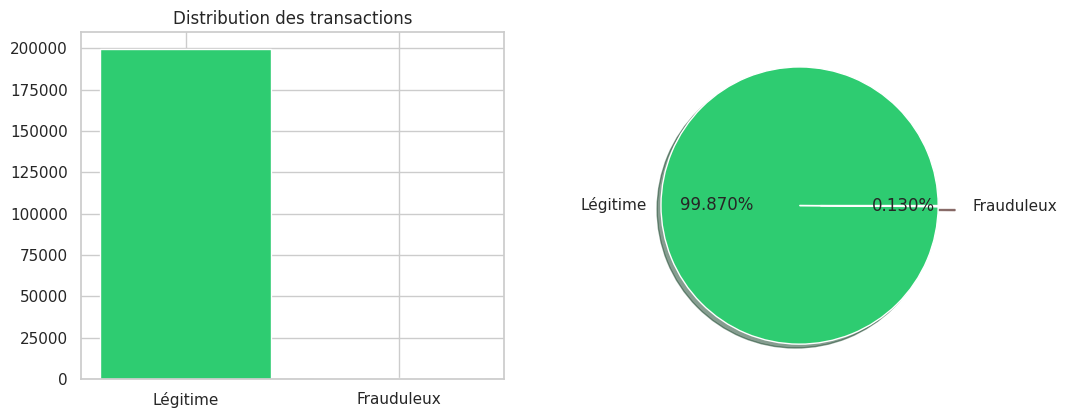

In [6]:
fraud_counts = data['isFraud'].value_counts()
fraud_pct = data['isFraud'].value_counts(normalize=True) * 100
print(fraud_counts)
print(fraud_pct.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(['Légitime', 'Frauduleux'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des transactions')
axes[1].pie(fraud_counts.values, labels=['Légitime', 'Frauduleux'], autopct='%1.3f%%',
            colors=['#2ecc71', '#e74c3c'], explode=(0, 0.15), shadow=True)
plt.show()

On observe un très fort déséquilibre des classes (~0.13% de fraude). Ce déséquilibre nécessite des métriques adaptées (recall, F1, ROC-AUC) et une stratégie de rééquilibrage (SMOTE) lors de la modélisation.

### Fraude selon le type de transaction

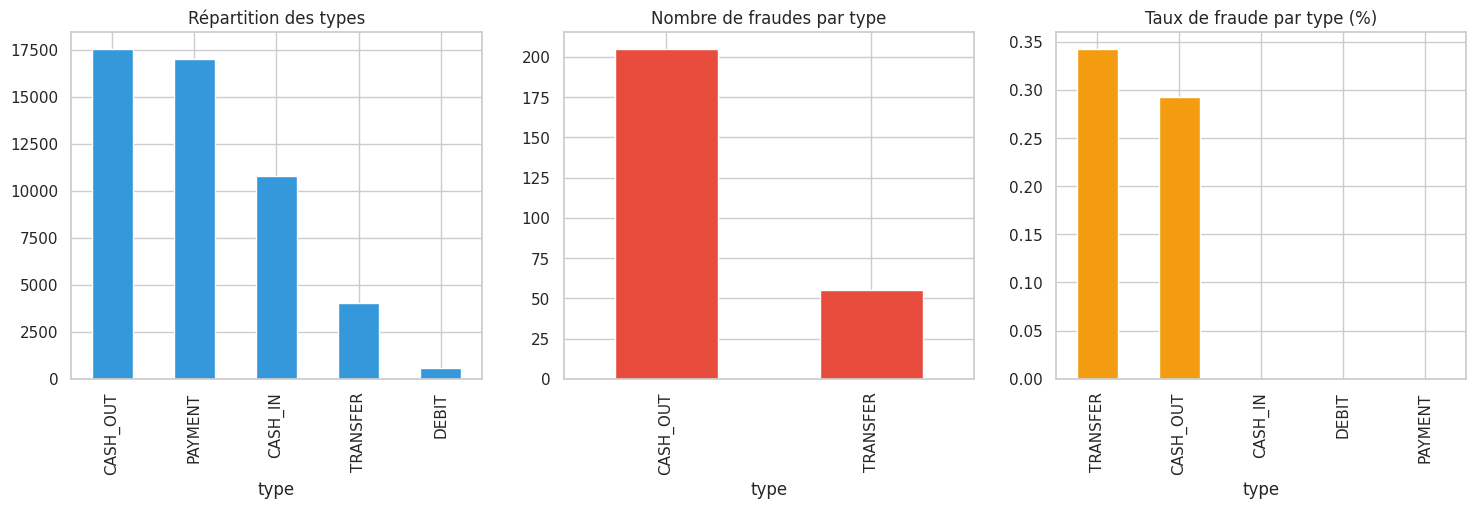

In [7]:
fraud_by_type = data[data['isFraud']==1]['type'].value_counts()
fraud_rate = (fraud_by_type / data['type'].value_counts() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
data_sample['type'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Répartition des types')
fraud_by_type.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Nombre de fraudes par type')
fraud_rate.plot(kind='bar', ax=axes[2], color='#f39c12')
axes[2].set_title('Taux de fraude par type (%)')
plt.show()

Les fraudes sont concentrées sur `TRANSFER` et `CASH_OUT` — cohérent avec des scénarios réels où les fraudeurs cherchent à transférer ou retirer rapidement des fonds.

### Montants

/tmp/ipykernel_201/3813308458.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Légitime', 'Frauduleux'])


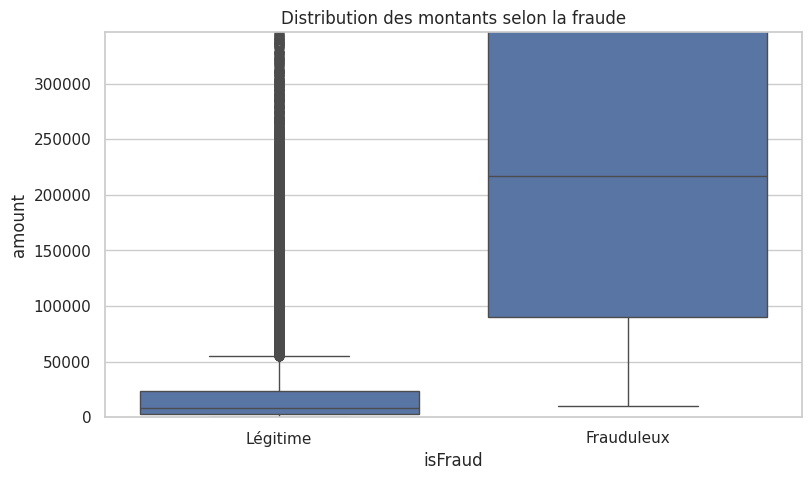

In [8]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(x='isFraud', y='amount', data=data_sample, ax=ax)
ax.set_ylim(0, data_sample['amount'].quantile(0.99))
ax.set_xticklabels(['Légitime', 'Frauduleux'])
ax.set_title('Distribution des montants selon la fraude')
plt.show()

### Incohérences de solde

In [9]:
tmp = data.copy()
tmp['balanceOrig_diff'] = tmp['newbalanceOrig'] - tmp['oldbalanceOrg']
tmp['balanceDest_diff'] = tmp['newbalanceDest'] - tmp['oldbalanceDest']
tmp['amount_check_orig'] = np.abs(tmp['balanceOrig_diff'] + tmp['amount']) < 0.01
tmp['amount_check_dest'] = np.abs(tmp['balanceDest_diff'] - tmp['amount']) < 0.01
suspicious = tmp[~tmp['amount_check_orig'] | ~tmp['amount_check_dest']]
print(f"Taux de fraude (incohérence de solde) : {suspicious['isFraud'].mean()*100:.2f}%")
print(f"Taux de fraude global : {data['isFraud'].mean()*100:.3f}%")

Taux de fraude (incohérence de solde) : 0.02%
Taux de fraude global : 0.130%


Les incohérences entre soldes déclarés et montant de la transaction sont fortement corrélées à la fraude → utilisées comme variables dérivées (`errorBalanceOrig`, `errorBalanceDest`) dans `src/preprocessing.py`.

### Matrice de corrélation

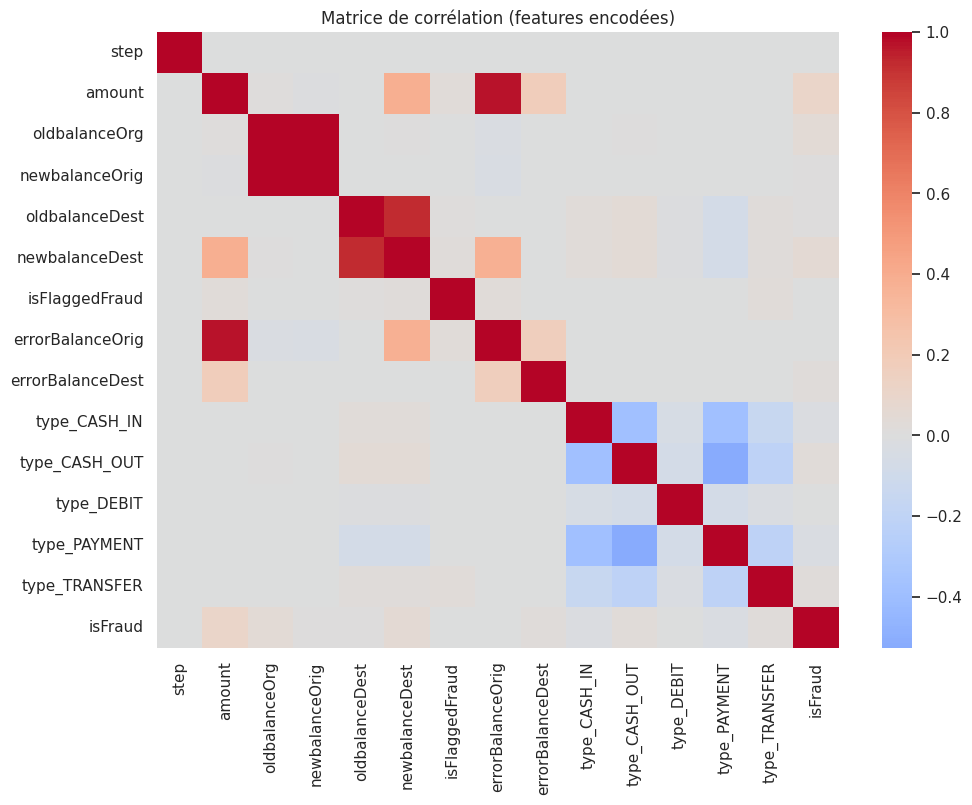

isFraud             1.000000
amount              0.104189
newbalanceDest      0.047272
oldbalanceOrg       0.042845
type_CASH_OUT       0.033171
type_TRANSFER       0.017435
errorBalanceDest    0.016751
oldbalanceDest      0.006953
newbalanceOrig      0.005294
errorBalanceOrig    0.000561
isFlaggedFraud     -0.000255
step               -0.001390
type_DEBIT         -0.003646
type_CASH_IN       -0.019121
type_PAYMENT       -0.025919
Name: isFraud, dtype: float64

In [10]:
model_frame = prepare_model_frame(data)
corr_frame = model_frame.copy()
corr_frame['isFraud'] = data['isFraud'].values
corr = corr_frame.corr()

plt.figure(figsize=(11,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (features encodées)')
plt.show()

corr['isFraud'].sort_values(ascending=False)

## 3. Préparation des données
Encodage one-hot de `type`, ajout des variables d'erreur de solde (`errorBalanceOrig`, `errorBalanceDest`), suppression des identifiants (`nameOrig`, `nameDest`, non généralisables).

In [11]:
X = prepare_model_frame(data)
y = data['isFraud']
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,538.0,503.93,128871.35,128367.42,105091.39,105595.32,0.0,-1.455192e-11,-1.455192e-11,0.0,1.0,0.0,0.0,0.0
1,594.0,1034280.36,0.00,0.00,5015.20,1039295.56,0.0,1.034280e+06,-1.164153e-10,1.0,0.0,0.0,0.0,0.0
2,15.0,13078.93,109747.07,96668.14,31613.31,44692.24,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,1.0,0.0
3,42.0,1008.76,0.00,0.00,9075.71,10084.47,0.0,1.008760e+03,0.000000e+00,0.0,1.0,0.0,0.0,0.0
4,383.0,21513.02,6274.63,0.00,0.00,21513.02,0.0,1.523839e+04,0.000000e+00,0.0,0.0,0.0,1.0,0.0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

(160000, 14) (40000, 14)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Gestion du déséquilibre — SMOTE
SMOTE est appliqué **uniquement sur l'ensemble d'entraînement**, après le split, pour éviter toute fuite de données (data leakage) entre train et test.

In [14]:
print("Avant SMOTE :", dict(pd.Series(y_train).value_counts()))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Après SMOTE :", dict(pd.Series(y_train_sm).value_counts()))

Avant SMOTE : {0: np.int64(159792), 1: np.int64(208)}


Après SMOTE : {0: np.int64(159792), 1: np.int64(159792)}


## 5. Modélisation
Trois modèles sont entraînés sur les données rééquilibrées par SMOTE, puis évalués sur l'ensemble de test **original** (non rééquilibré) pour refléter des conditions réalistes.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    fitted_models[name] = model
    print(f"\n🔹 {name}")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     39948
           1       0.04      0.88      0.08        52

    accuracy                           0.97     40000
   macro avg       0.52      0.93      0.53     40000
weighted avg       1.00      0.97      0.99     40000




🔹 Random Forest
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     39948
           1       0.15      0.92      0.26        52

    accuracy                           0.99     40000
   macro avg       0.57      0.96      0.63     40000
weighted avg       1.00      0.99      1.00     40000




🔹 XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39948
           1       0.29      0.85      0.43        52

    accuracy                           1.00     40000
   macro avg       0.64      0.92      0.71     40000
weighted avg       1.00      1.00      1.00     40000



## 6. Comparaison Precision / Recall / F1 / ROC-AUC

In [16]:
results_df = pd.DataFrame(results).T.round(4)[["accuracy","precision","recall","f1","roc_auc"]]
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9734,0.0416,0.8846,0.0795,0.9873
Random Forest,0.9930,0.1481,0.9231,0.2553,0.9979
XGBoost,0.9970,0.2857,0.8462,0.4272,0.9950


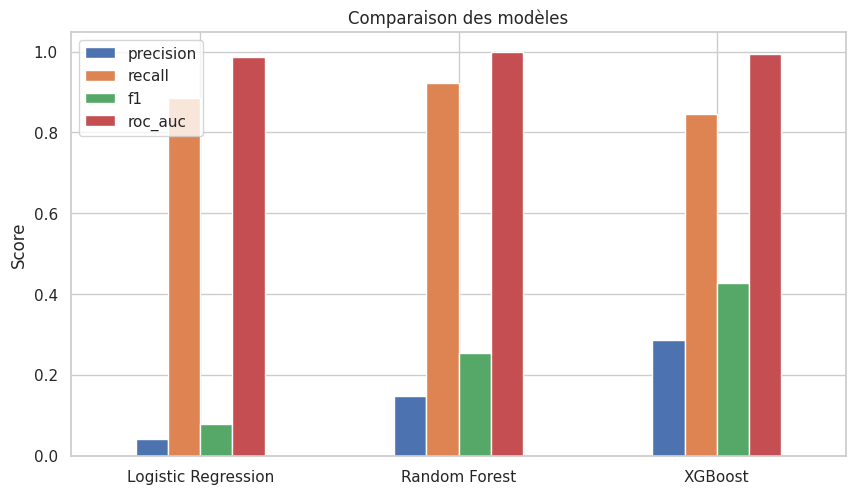

In [17]:
fig, ax = plt.subplots(figsize=(10,5.5))
results_df[["precision","recall","f1","roc_auc"]].plot(kind='bar', ax=ax)
ax.set_title("Comparaison des modèles")
ax.set_ylabel("Score")
ax.set_xticklabels(results_df.index, rotation=0)
plt.show()

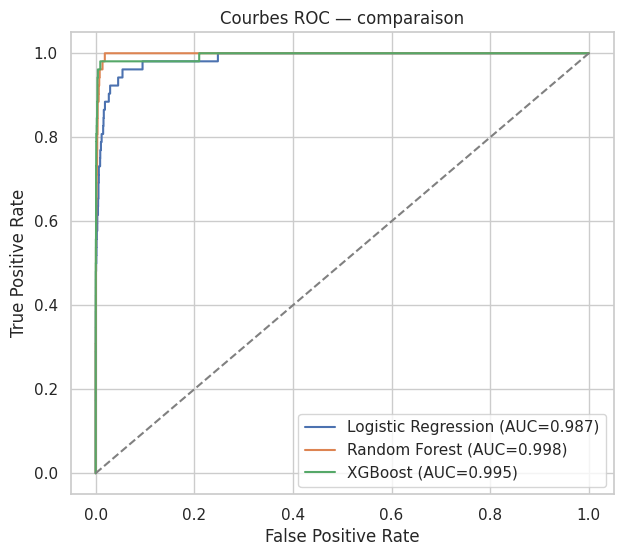

In [18]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], linestyle='--', color='grey')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Courbes ROC — comparaison")
ax.legend(loc='lower right')
plt.show()

**Lecture des résultats :**
- La régression logistique offre une baseline interprétable mais une precision très faible (beaucoup de faux positifs) malgré un bon recall.
- Random Forest améliore nettement le F1-score grâce à sa capacité à capturer des interactions non linéaires.
- XGBoost obtient le meilleur compromis precision/recall (meilleur F1-score), ce qui en fait le modèle retenu pour l'application de prédiction.

## 7. Matrices de confusion

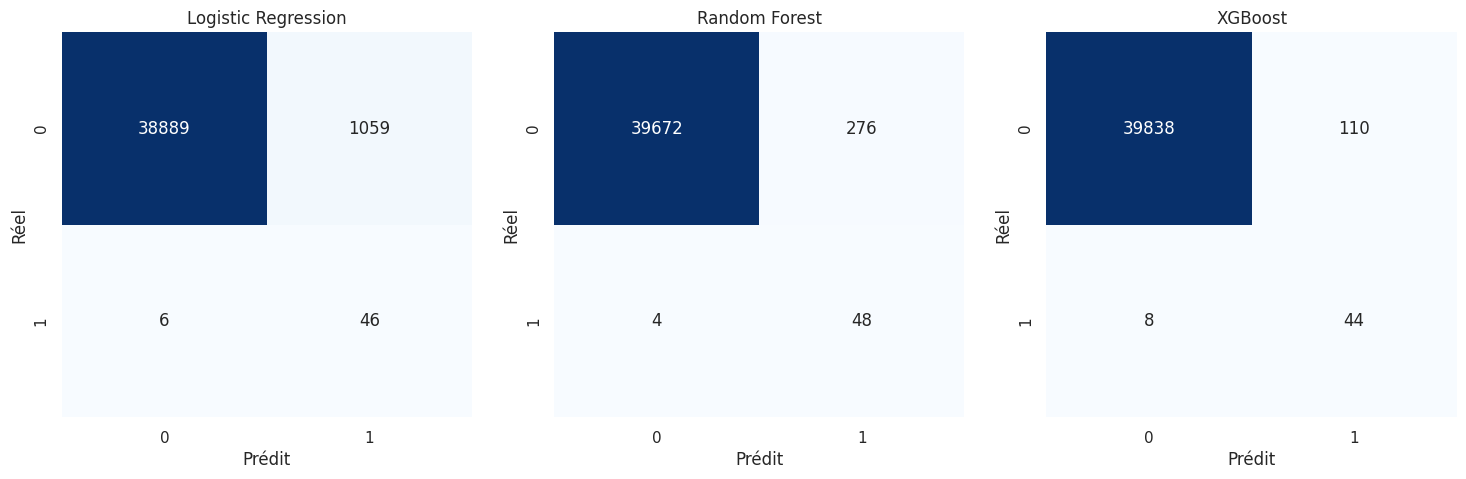

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.show()

## 8. Feature importance

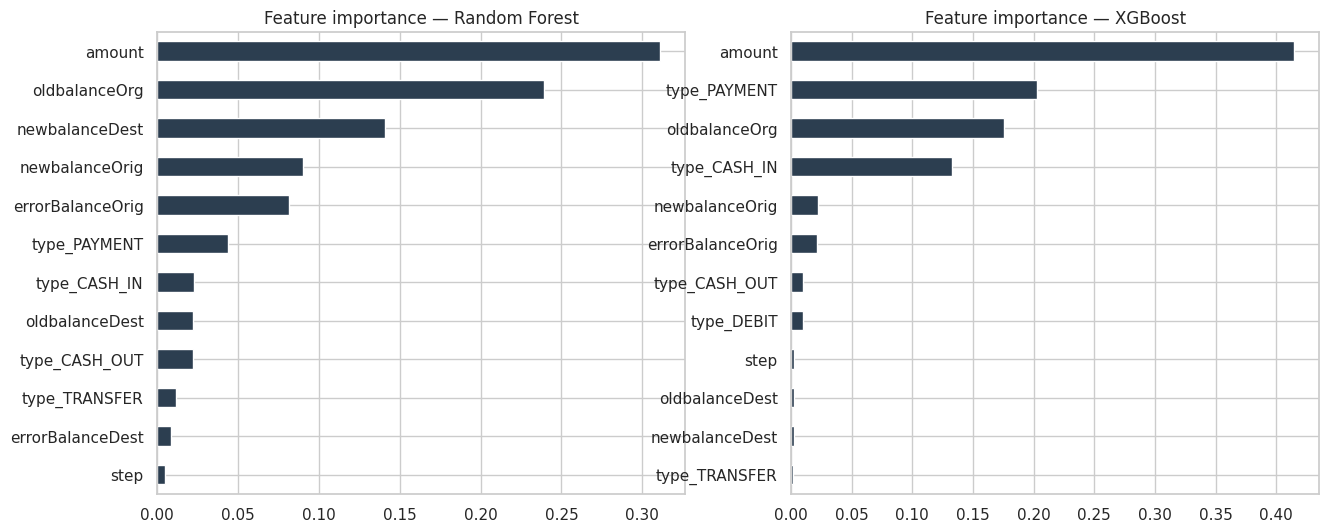

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    model = fitted_models[name]
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importances.tail(12).plot(kind='barh', ax=ax, color='#2c3e50')
    ax.set_title(f"Feature importance — {name}")
plt.show()

Le montant, les soldes du compte émetteur/destinataire et les variables d'erreur de solde ressortent comme les signaux les plus discriminants, ce qui confirme les observations faites en EDA.

## 9. Interprétabilité — SHAP (XGBoost)

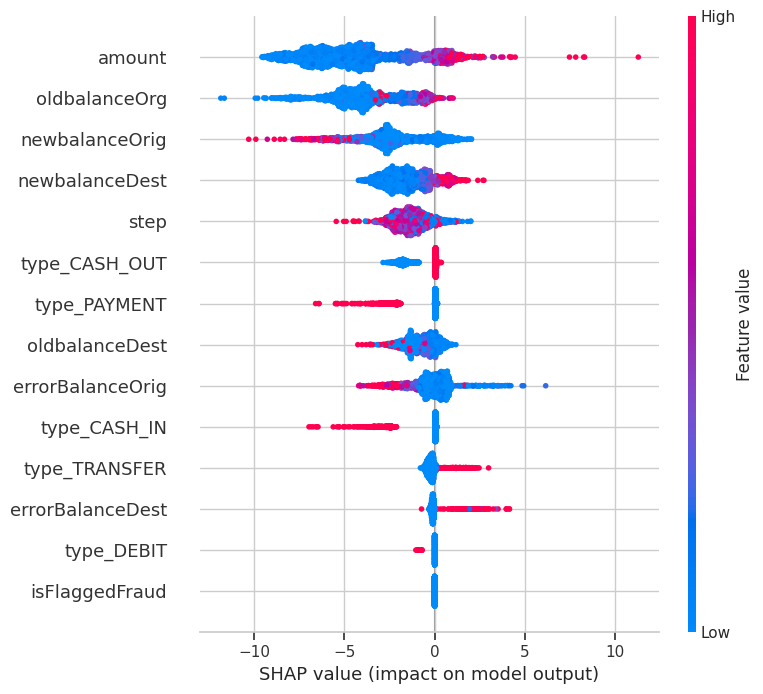

In [21]:
explainer = shap.TreeExplainer(fitted_models["XGBoost"])

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_scaled), size=2000, replace=False)
X_shap_sample = X_test_scaled[sample_idx]

shap_values = explainer.shap_values(X_shap_sample)
shap.summary_plot(shap_values, X_shap_sample, feature_names=X.columns.tolist())

Le SHAP summary plot confirme et affine la feature importance globale : il montre en plus le **sens** de l'effet de chaque variable (une erreur de solde élevée ou un montant atypique pousse la prédiction vers la fraude).

## 10. Conclusion générale

Ce projet construit un système complet de détection de fraude : EDA approfondie, feature engineering, gestion du fort déséquilibre de classes via SMOTE, comparaison rigoureuse de trois modèles (Logistic Regression, Random Forest, XGBoost) sur des métriques adaptées, et interprétabilité via feature importance et SHAP.

**XGBoost** offre le meilleur F1-score et un bon compromis precision/recall : c'est le modèle sauvegardé et utilisé par l'application interactive (`app/app.py`) qui permet de saisir les caractéristiques d'une transaction et d'obtenir une prédiction fraude/légitime en temps réel.

Pistes d'amélioration : seuil de décision ajustable selon le coût métier des faux positifs/négatifs, recalibrage sur le vrai dataset Kaggle (6.3M lignes), suivi de dérive du modèle en production.